Epoch 01 | Loss: 0.7222 | LR: 0.5
Epoch 05 | Loss: 0.6816 | LR: 0.5
Epoch 10 | Loss: 0.6397 | LR: 0.5
Epoch 15 | Loss: 0.5992 | LR: 0.5
Epoch 20 | Loss: 0.5693 | LR: 0.5
Epoch 25 | Loss: 0.5317 | LR: 0.5
Epoch 30 | Loss: 0.4968 | LR: 0.5
Epoch 35 | Loss: 0.4494 | LR: 0.5
Epoch 40 | Loss: 0.4682 | LR: 0.5
Epoch 45 | Loss: 0.4173 | LR: 0.5
Epoch 50 | Loss: 0.3413 | LR: 0.5


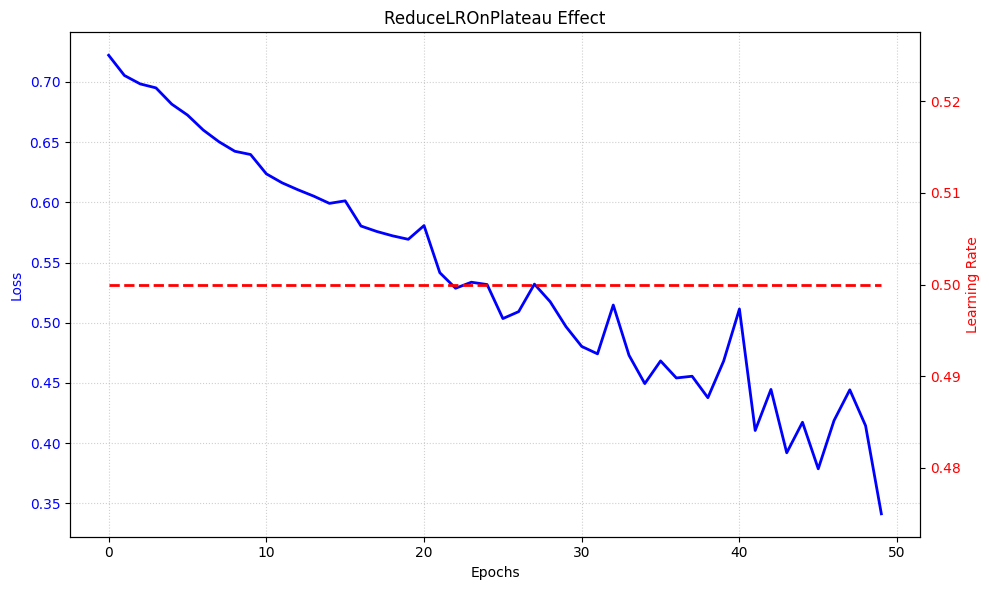

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt  # <- 누락되었던 matplotlib 추가

# 1. 인위적으로 데이터셋 생성
X = torch.randn(1000, 20)
y = torch.randint(0, 2, (1000,))
dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

# 2. 모델, 손실함수, 옵티마이저 정의
model = nn.Sequential(nn.Linear(20, 50), nn.ReLU(), nn.Linear(50, 2))
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.5) # 초반엔 큰 보폭

# 학습률이 정체될 때 0.1배로 줄여주는 스케줄러 정의
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.1)

loss_history = []
lr_history = []

# 3. 학습 루프
for epoch in range(50):
    epoch_loss = 0.0
    for batch_X, batch_y in loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(loader)
    loss_history.append(avg_loss)
    lr_history.append(optimizer.param_groups[0]['lr'])

    # 스케줄러에게 현재 훈련 손실을 전달하여 정체 여부 판단
    scheduler.step(avg_loss)

    # 학습 과정을 콘솔에 출력 (선택 사항)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | LR: {lr_history[-1]}")

# 4. 결과 그래프 출력 (Loss와 Learning Rate를 twinx로 동시에 그리기)
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss', color='blue')
ax1.plot(loss_history, color='blue', label='Loss', linewidth=2)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, linestyle=':', alpha=0.6)

ax2 = ax1.twinx()
ax2.set_ylabel('Learning Rate', color='red')
ax2.plot(lr_history, color='red', linestyle='--', label='LR', linewidth=2)
ax2.tick_params(axis='y', labelcolor='red')

plt.title('ReduceLROnPlateau Effect')
fig.tight_layout()
plt.show()